In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/Folder lilis, oki jangan sentuh/colab lilis/dataset.zip" -d "/content/drive/MyDrive/Folder lilis, oki jangan sentuh/colab lilis"

Archive:  /content/drive/MyDrive/Folder lilis, oki jangan sentuh/colab lilis/dataset.zip
replace /content/drive/MyDrive/Folder lilis, oki jangan sentuh/colab lilis/dataset/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image
y
#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_data_path = "/content/drive/MyDrive/Folder lilis, oki jangan sentuh/colab lilis/dataset/Training"

filepaths = []
labels = []

folds = os.listdir(train_data_path)

for fold in folds:
  f_path = os.path.join(train_data_path, fold)
  if os.path.isdir(f_path):
    filelists = os.listdir(f_path)

    for file in filelists:
      filepaths.append(os.path.join(f_path, file))
      labels.append(fold)

#Concat data path with labels
Fseries =  pd.Series(filepaths, name = 'filepaths')
Lseries = pd.Series(labels , name = 'labels')
train_df = pd.concat([Fseries , Lseries] , axis = 1)



In [ ]:
train_df

,filepaths,labels
0,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
1,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
2,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
3,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
4,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
...,...,...
5707,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma
5708,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma
5709,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma
5710,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma


In [ ]:
test_data_path = "/content/drive/MyDrive/Folder lilis, oki jangan sentuh/colab lilis/dataset/Testing"

filepaths = []
labels = []

folds = os.listdir(test_data_path)

for fold in folds:
  f_path = os.path.join(test_data_path, fold)
  if os.path.isdir(f_path):
    filelists = os.listdir(f_path)

    for file in filelists:
      filepaths.append(os.path.join(f_path, file))
      labels.append(fold)

#Concat data path with labels
Fseries =  pd.Series(filepaths, name = 'filepaths')
Lseries = pd.Series(labels , name = 'labels')
test_df = pd.concat([Fseries , Lseries] , axis = 1)

In [ ]:
test_df

,filepaths,labels
0,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
1,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
2,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
3,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
4,"/content/drive/MyDrive/Folder lilis, oki janga...",pituitary
...,...,...
1306,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma
1307,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma
1308,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma
1309,"/content/drive/MyDrive/Folder lilis, oki janga...",meningioma


In [ ]:
img_size = (224 ,244)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

# Split train_df into training and validation sets
from sklearn.model_selection import train_test_split
train_df_split, valid_df = train_test_split(train_df, train_size=0.8, random_state=42, stratify=train_df['labels'])

train_gen = tr_gen.flow_from_dataframe(train_df_split , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df , x_col= 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 4569 validated image filenames belonging to 4 classes.
Found 1143 validated image filenames belonging to 4 classes.
Found 1311 validated image filenames belonging to 4 classes.


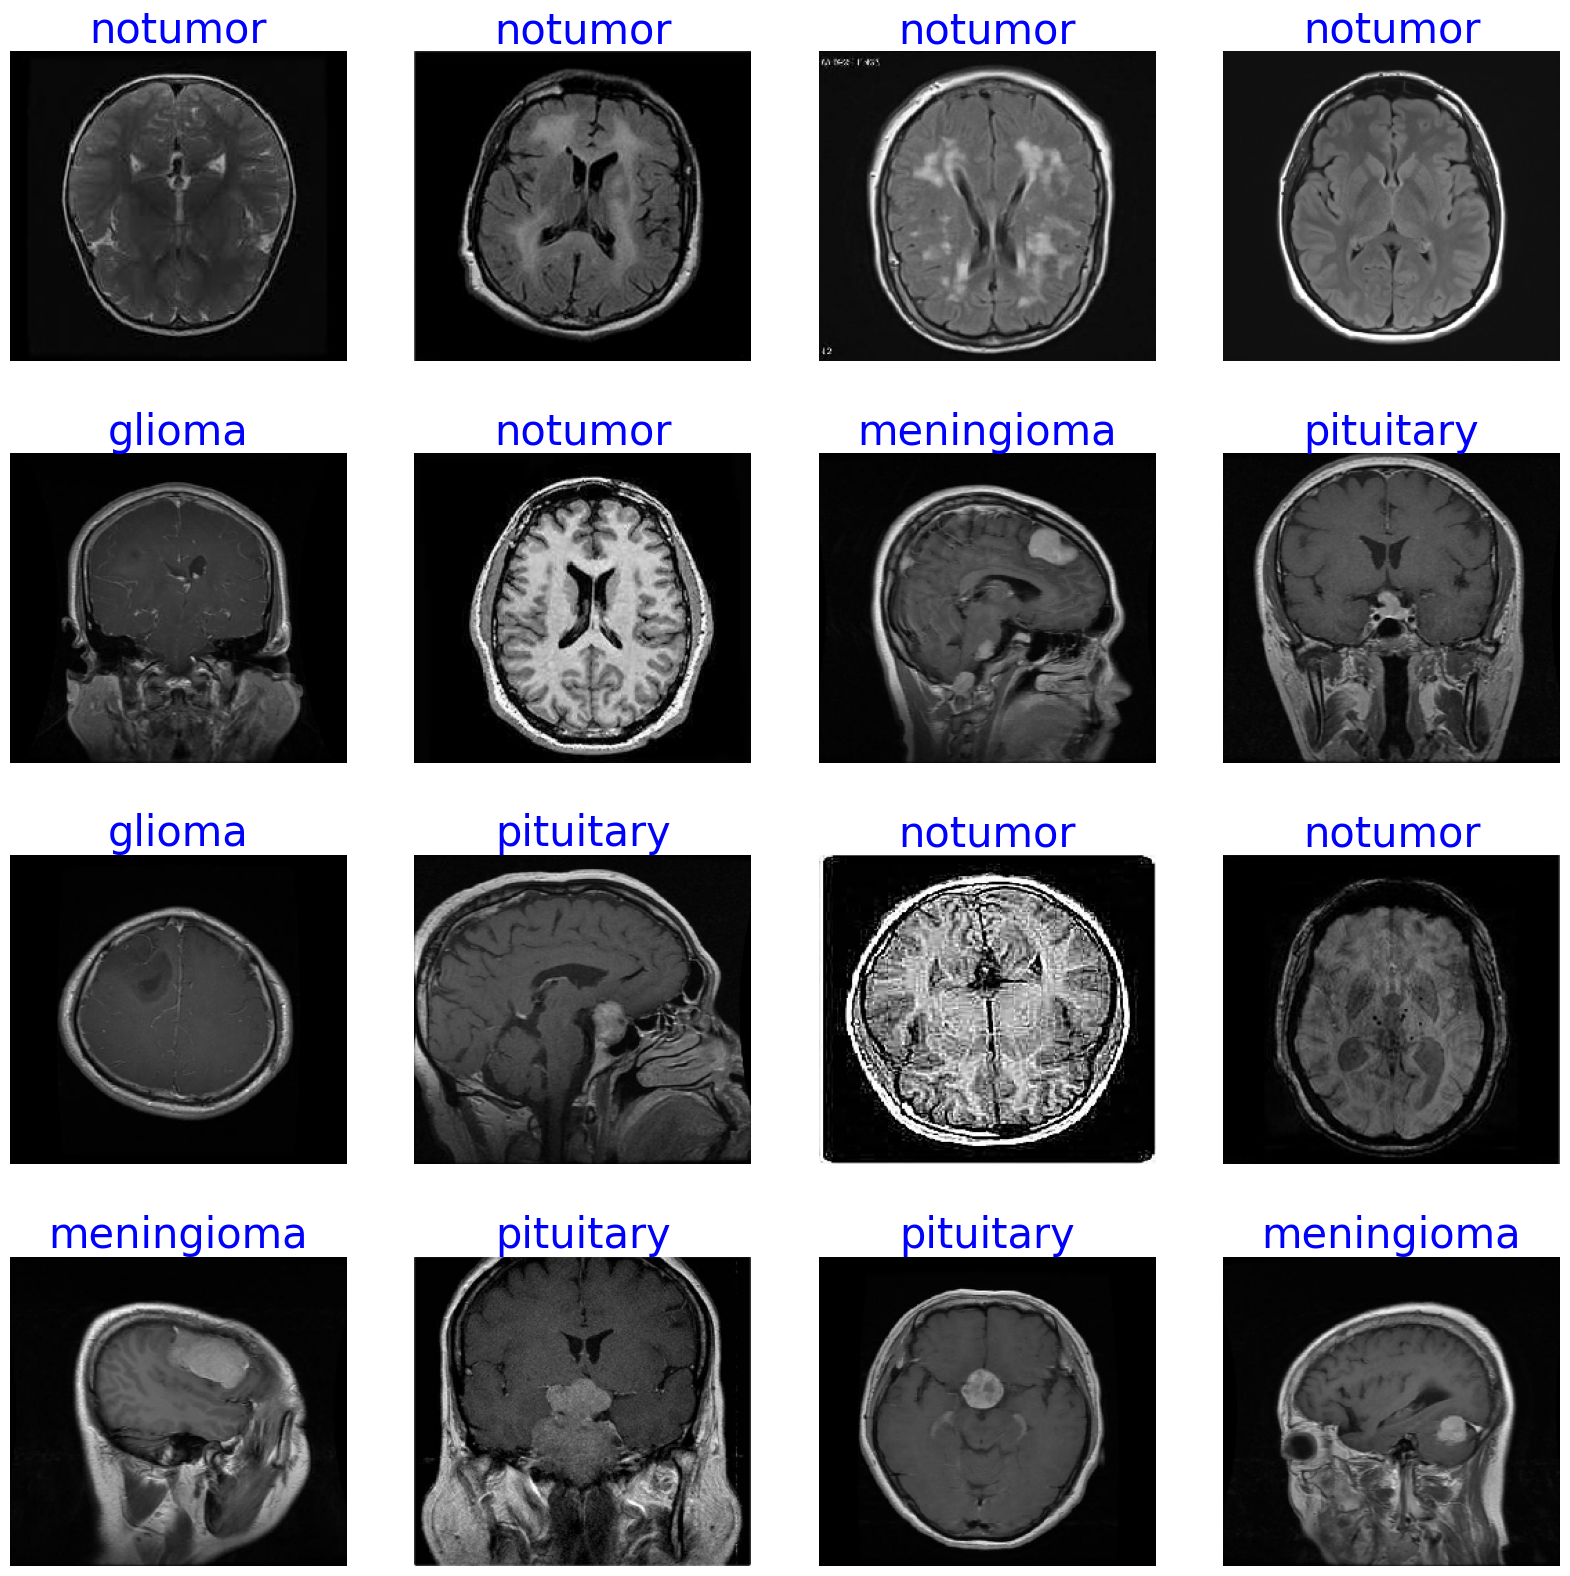

In [ ]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize= (20,20))

for i in range(16):
  plt.subplot(4,4,i+1)
  image = images[i] / 255
  plt.imshow(image)
  index = np.argmax(labels[i])
  class_name = classes[index]
  plt.title(class_name, color = "blue", fontsize = 30)
  plt.axis("off")
plt.show();

In [ ]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 6,190,228 (23.61 MB)

 Non-trainable params: 63,168 (246.75 KB)

In [ ]:
Epochs = 18

history = model.fit(
  train_gen,
  epochs=Epochs,
  verbose=1,
  validation_data=valid_gen,
  shuffle=True,
)

Epoch 1/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 184s 327ms/step - accuracy: 0.5550 - loss: 11.1571 - val_accuracy: 0.3421 - val_loss: 5.9483
Epoch 2/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.3993 - loss: 5.4933 - val_accuracy: 0.5774 - val_loss: 4.3046
Epoch 3/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - accuracy: 0.4703 - loss: 3.9570 - val_accuracy: 0.5328 - val_loss: 3.0647
Epoch 4/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 34s 120ms/step - accuracy: 0.5526 - loss: 2.8583 - val_accuracy: 0.7288 - val_loss: 2.2090
Epoch 5/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - accuracy: 0.7292 - loss: 2.1081 - val_accuracy: 0.8618 - val_loss: 1.6064
Epoch 6/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 34s 118ms/step - accuracy: 0.8505 - loss: 1.5796 - val_accuracy: 0.8889 - val_loss: 1.2601
Epoch 7/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 33s 114ms/step - accuracy: 0.8915 - loss: 1.2791 - val_accuracy: 0.9309 - val_loss: 1.0036
Epoch 8/18
286/286 ━━━━━━━━━━━━━━━━━━━━ 37s 129ms/step - accuracy: 0.9116 - loss:

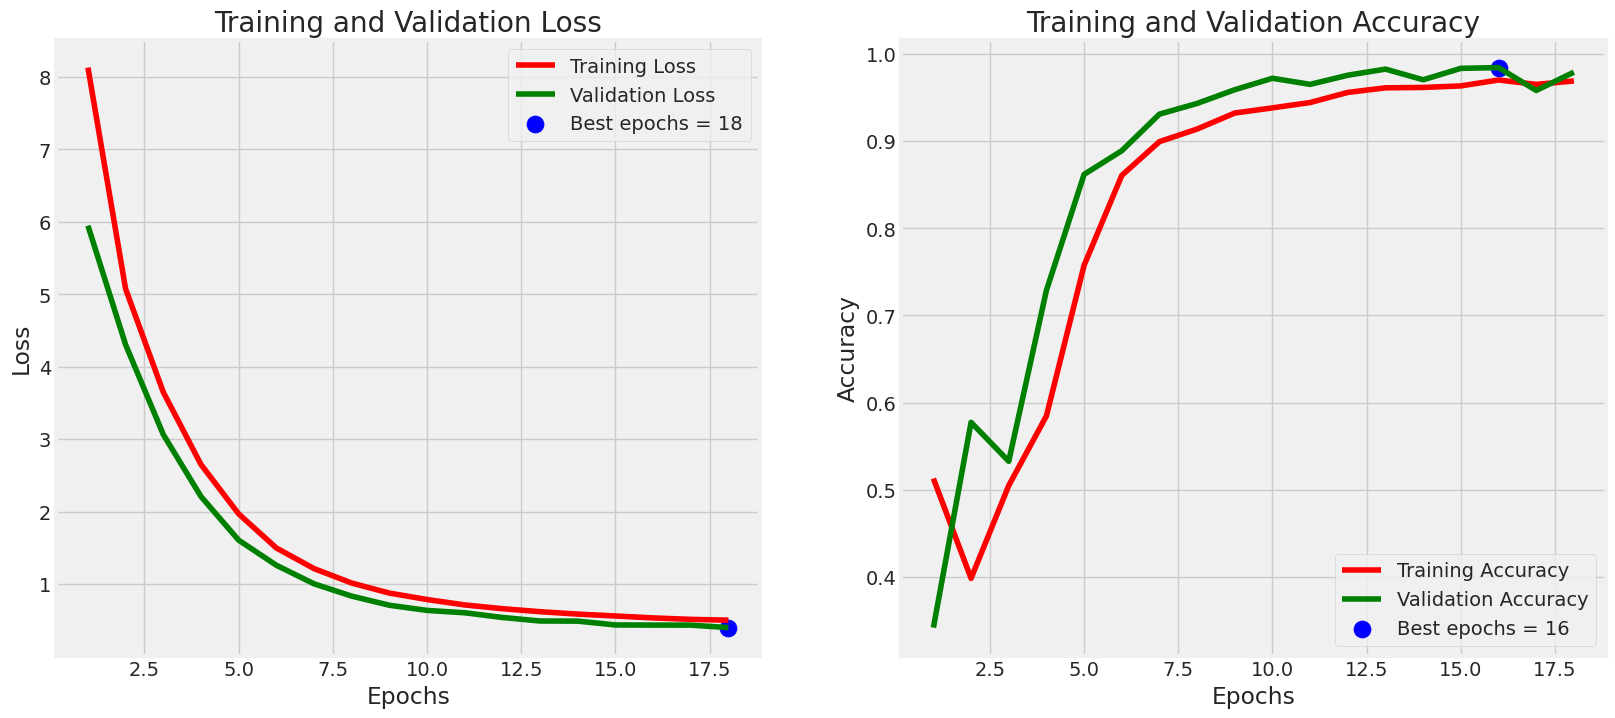

In [ ]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show();

In [ ]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 1.0000 - loss: 0.3626
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9648 - loss: 0.4278
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9863 - loss: 0.3591
Train Loss:  0.3565194606781006
Train Accuracy:  1.0
--------------------
Validation Loss:  0.42299848794937134
Validation Accuracy:  0.96875
--------------------
Test Loss:  0.35635071992874146
Test Accuracy:  0.98828125


In [ ]:
preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

82/82 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step


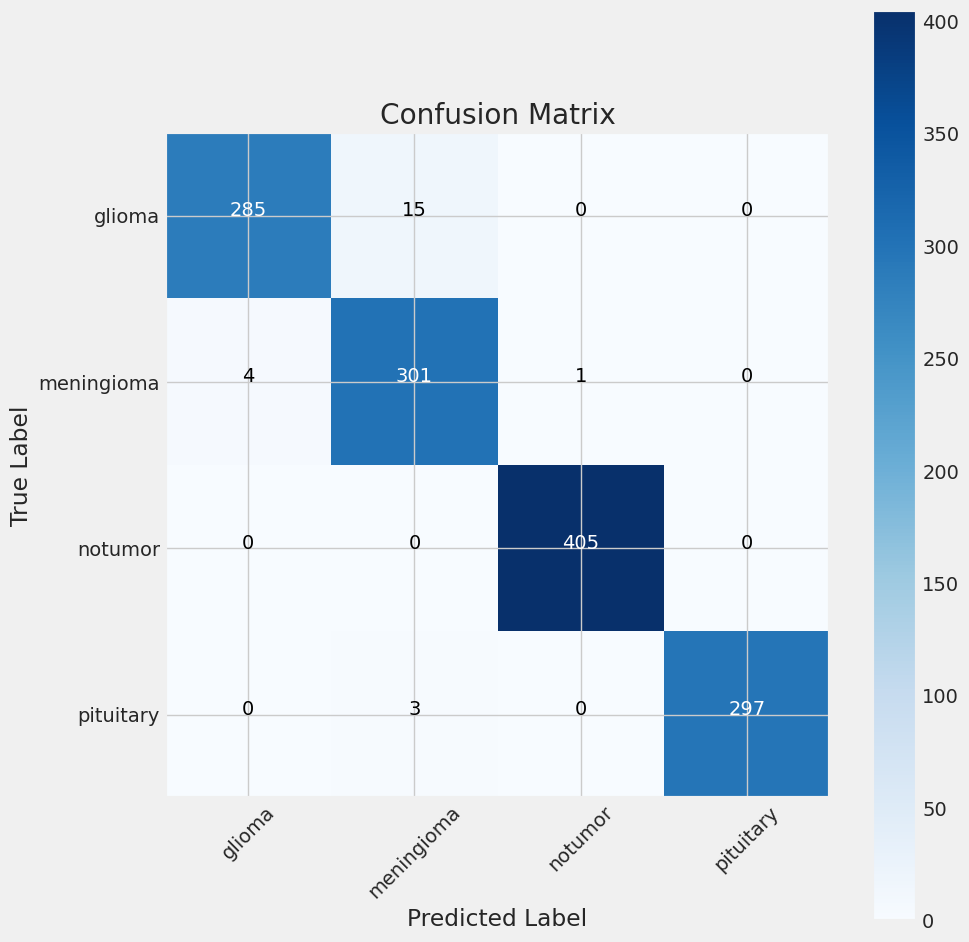

In [ ]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [ ]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

      glioma       0.99      0.95      0.97       300
  meningioma       0.94      0.98      0.96       306
     notumor       1.00      1.00      1.00       405
   pituitary       1.00      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311



In [ ]:
model.save("model.h5")

In [ ]:
from keras.models import load_model
from keras.preprocessing import image
import numpy as np

In [ ]:

model = load_model('model.h5', compile=False)
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [ ]:
gambar = tf.keras.preprocessing.image.load_img('/content/drive/MyDrive/Folder lilis, oki jangan sentuh/colab lilis/dataset/Testing/glioma/Te-glTr_0000.jpg', target_size=img_size)

In [ ]:
input_arr = tf.keras.preprocessing.image.img_to_array(gambar)

In [ ]:
input_arr = np.array([input_arr])
prediksi = model.predict(input_arr)
predicted_class = np.argmax(prediksi, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


In [ ]:
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
print(predicted_class)

[0]


In [ ]:
names = [classes[i] for i in predicted_class]
print(names)

['glioma']
